<h1> Use of the Experiment class </h1>

In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
pi = np.pi
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports

from src.xp_config import ExperimentConfig
from src.experiment import Experiment
from src.bare_param import get_bare_param_n

<h2> Generate an initial configutation </h1>

The initial configuration is as follows:
- Monochromatic photonic wave packet $(\omega_p, \Delta_k, x_0)$ for both photons
- Atom and cavity length $(\omega_0, \gamma, L)$
- Time evolution $(T, dt)$
- IR and UV cutoffs $(\Lambda_{\rm IR}, \Lambda_{\rm UV})$

In [2]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Incoming photons
omega_q = 9*pi
delta_q = 0.05*pi

#Frequency window
ir = 2*pi
uv = 25*pi

omega_ref = 1/2*(ir + uv)
lbda = 1/2*(uv - ir)

print(f"Bandwith : {lbda/pi:.3f} pi")


cutoffs = {'ir_cutoff': ir , 'uv_cutoff': uv}

#Bare parameters
omega_0, gamma = get_bare_param_n(omega_A, Gamma, ir, uv, n=3)
#omega_0, gamma = get_bare_param(omega_A, Gamma, ir, uv)


#Parameters of the simulation
L = 50

param_cavity = {'omega_0': omega_0, 'gamma': gamma, 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

param_photons = {'omega_p': [omega_q, omega_q], 
                 'delta_k': [delta_q, delta_q],
                 'x_0': [-L/4, -L/4]}

print(f"omega_0 = {omega_0:.5f}, gamma = {gamma:.5f} \n --------------")

Bandwith : 11.500 pi
omega_0 = 32.70808, gamma = 13.66869 
 --------------


<h2> Run an experiment </h2>

Don't store the state unless necessary (costs lot ot memory)

In [3]:
config = ExperimentConfig(param_photons, param_cavity, param_time_evol, cutoffs, store_state=False)
scattering_experiment = Experiment(config)
c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)

#Check eventual messages
messages = scattering_experiment.get_messages()
 
#Compute observables
An_array, P11n_array, P12n_array, P21n_array, P22n_array = scattering_experiment.compute_observables(progress=True)
#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2499/2499 [02:40<00:00, 15.53it/s]


Numerical checks

In [5]:
C = P12n_array[-1] + P21n_array[-1]
#C = np.nan

#Compute the theoretical value towards which the three curves should converge
R_theory_physical = 1 / (1 + ((omega_q - omega_A)/ (Gamma/2))**2)
theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

if np.abs(theoretical_val) < 1e-1:
    non_monochr_ratio = Gamma / (2*delta_q)
    theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)

relative_error = np.abs(C - theoretical_val) / np.abs(theoretical_val)

print(f"Theoretical prediction : {theoretical_val:.5f} ")
print(f"Numerical estimation : {C:.5f} ")
print(f"Relative error : {relative_error*100:.3f} %")

Theoretical prediction : 0.52438 
Numerical estimation : 0.53166 
Relative error : 1.389 %


<h2> Visualize excitation numbers </h2>

Get the observables and generate a time array for the figure

In [10]:
config = ExperimentConfig(param_photons, param_cavity, param_time_evol, cutoffs)
scattering_experiment = Experiment(config)
c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)

#Check eventual messages
messages = scattering_experiment.get_messages()

time_array = np.arange(0, param_time_evol['T'], param_time_evol['dt'])   
#Compute observables
An_array, P11n_array, P12n_array, P21n_array, P22n_array = scattering_experiment.compute_observables(progress=True)
#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2500/2500 [02:39<00:00, 15.69it/s]


Figure

Anti HOM probability : 0.9832490477633523


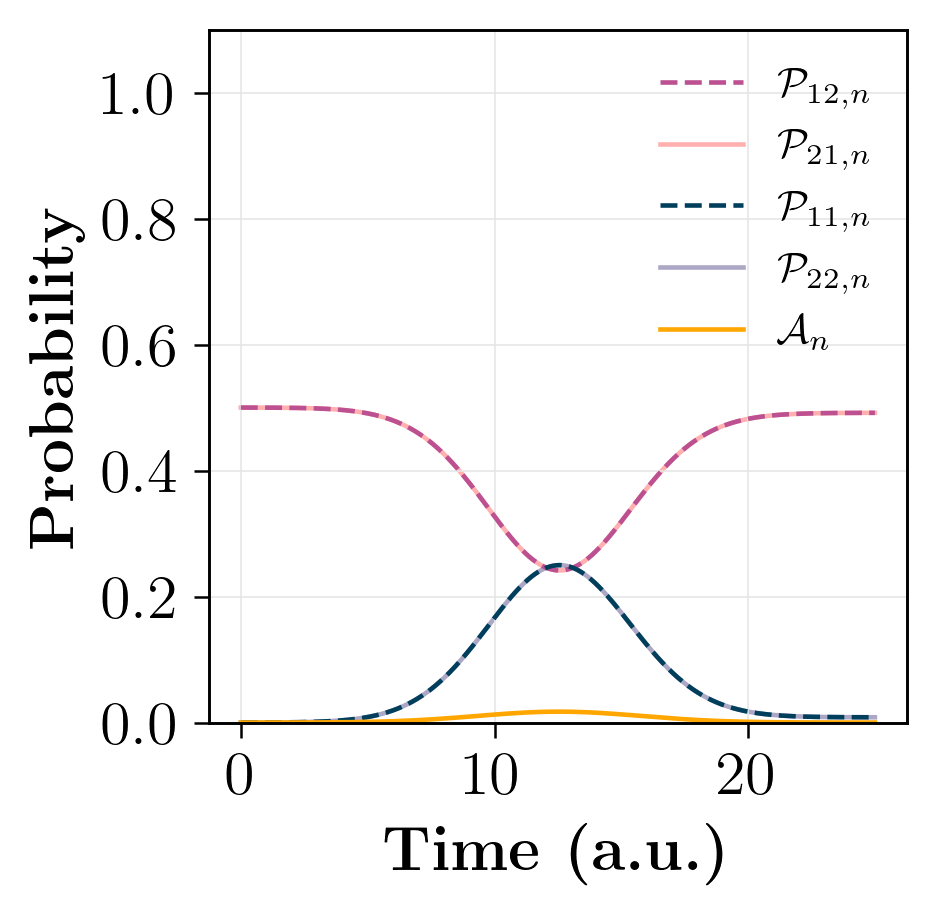

In [11]:
print("Anti HOM probability :", P12n_array[-1] + P21n_array[-1])

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)


color_P11 = '#003f5c'     
color_P22 = '#58508d'     

color_P12 = '#bc5090'     
color_P21 = '#ff6361'     



color_atom = '#ffa600'

# ---- courbes lisses ----

ax.plot(time_array, P12n_array , linestyle='--', color=color_P12, lw=1.1, label=r'$\mathcal{P}_{12, n}$', alpha=1, zorder=2)
ax.plot(time_array, P21n_array , linestyle='-', color=color_P21, lw=1.1, label=r'$\mathcal{P}_{21, n}$', alpha=0.5, zorder=0)

ax.plot(time_array, P11n_array , linestyle='--', color=color_P11, lw=1.1, label=r'$\mathcal{P}_{11, n}$',alpha=1, zorder=2)
ax.plot(time_array, P22n_array , linestyle='-', color=color_P22, lw=1.1, label=r'$\mathcal{P}_{22, n}$', alpha=0.5, zorder=0)

ax.plot(time_array, An_array, '-', color=color_atom, lw=1.1, label=r'$\mathcal{A}_n$')


# Labels, limites et grille
ax.set_xlabel(r'\textbf{Time (a.u.)}', fontsize=10)
ax.set_ylabel(r'\textbf{Probability}', fontsize=10)

ax.set_ylim([0,1.1])


ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="upper right", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

#plt.savefig("../results/fig/single_photon_example_1.25omega0.pdf", bbox_inches="tight")
plt.show()